# Engine de Monitoreo Transaccional y Mitigación de Fraude Operativo
## Estratega de Datos: Moisés Antonio Marín Bernal

### Resumen Ejecutivo:
Diseño y ejecución de un motor de auditoría de datos orientado a la banca comercial en México. 
El sistema automatiza la detección de anomalías transaccionales en tiempo real, enfocándose 
en la protección de activos mediante la identificación de patrones de fraude por proximidad 
y velocidad de cargo.

### Capacidades Técnicas del Proyecto:
* **Ingeniería de Datos:** Generación de flujos de datos sintéticos con lógica de negocio local (MXN).
* **Auditoría SQL:** Consultas de agregación avanzada para la detección de umbrales críticos de gasto.
* **Gobierno de Datos:** Estructura de repositorio profesional bajo estándares de escalabilidad.

In [1]:
import pandas as pd
import numpy as np

print("Entorno de Fraude configurado con éxito")

Entorno de Fraude configurado con éxito


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta  # ESTA ES LA LÍNEA QUE FALTABA

# 1. Configuración de comercios y ciudades nacionales
comercios_mx = ['OXXO', '7-Eleven', 'Mercado Libre', 'Amazon MX', 'Uber Eats', 'Walmart', 'Gasolinera Pemex', 'Apple Store']
ciudades_mx = ['Toluca', 'CDMX', 'Guadalajara', 'Monterrey', 'Querétaro', 'Puebla', 'Mérida', 'Cancún']

# 2. Generamos 1,000 transacciones con sabor local
np.random.seed(42)
n_rows = 1000
data_mx = {
    'id_transaccion': range(1, n_rows + 1),
    'id_usuario': np.random.randint(100, 150, n_rows),
    'monto_mxn': np.round(np.random.uniform(20, 12000), 2),
    'comercio': np.random.choice(comercios_mx, n_rows),
    'ciudad': np.random.choice(ciudades_mx, n_rows),
    'fecha_hora': [datetime(2026, 4, 1) + timedelta(minutes=np.random.randint(0, 40000)) for _ in range(n_rows)],
    'es_fraude': 0 
}

df_mx = pd.DataFrame(data_mx)

# 3. Inyectamos un fraude típico: "El Tarjetazo en Electrónica"
df_mx.loc[10:12, 'id_usuario'] = 140
df_mx.loc[10:12, 'monto_mxn'] = 11500.00
df_mx.loc[10:12, 'comercio'] = 'Apple Store'
df_mx.loc[10:12, 'ciudad'] = 'CDMX'
df_mx.loc[10:12, 'es_fraude'] = 1

base_time_mx = datetime(2026, 4, 28, 15, 30)
for i in range(3):
    df_mx.loc[10+i, 'fecha_hora'] = base_time_mx + timedelta(minutes=i*2)

print("Dataset Nacional generado con éxito.")
df_mx.iloc[10:15]

Dataset Nacional generado con éxito.


,id_transaccion,id_usuario,monto_mxn,comercio,ciudad,fecha_hora,es_fraude
10,11,140,11500.00,Apple Store,CDMX,2026-04-28 15:30:00,1
11,12,140,11500.00,Apple Store,CDMX,2026-04-28 15:32:00,1
12,13,140,11500.00,Apple Store,CDMX,2026-04-28 15:34:00,1
13,14,139,11205.63,Gasolinera Pemex,Puebla,2026-04-06 18:45:00,0
14,15,123,11205.63,Apple Store,Guadalajara,2026-04-20 18:55:00,0


In [3]:
# Guardamos el dataset nacional en nuestra carpeta de datos
df_mx.to_csv('../1_Data/transacciones_fraude_mx.csv', index=False)

print("¡Archivo guardado con éxito en 1_Data/transacciones_fraude_mx.csv!")

¡Archivo guardado con éxito en 1_Data/transacciones_fraude_mx.csv!


In [4]:
import sqlite3

# 1. Creamos una base de datos temporal (vive en la RAM de tu PC)
conexion = sqlite3.connect(':memory:')

# 2. Convertimos tu tabla de Python a una tabla SQL real
df_mx.to_sql('tabla_fraude', conexion, index=False, if_exists='replace')

print("Base de Datos Interna: LISTA")

Base de Datos Interna: LISTA


In [5]:
# Definimos la regla de negocio: más de 2 compras en el mismo lugar = SOSPECHOSO
query_estrategica = """
SELECT 
    id_usuario, 
    comercio, 
    ciudad, 
    COUNT(*) as numero_operaciones, 
    SUM(monto_mxn) as exposicion_total
FROM tabla_fraude
GROUP BY id_usuario, comercio, ciudad
HAVING numero_operaciones > 2
ORDER BY exposicion_total DESC
"""


alertas_fraude = pd.read_sql(query_estrategica, conexion)

print("ALERTA DE SEGURIDAD BANCARIA - PATRONES DETECTADOS:")
alertas_fraude

ALERTA DE SEGURIDAD BANCARIA - PATRONES DETECTADOS:


,id_usuario,comercio,ciudad,numero_operaciones,exposicion_total
0,121,Uber Eats,Cancún,4,44822.52
1,140,Apple Store,CDMX,3,34500.00
2,108,OXXO,Monterrey,3,33616.89
3,109,7-Eleven,Mérida,3,33616.89
4,118,Uber Eats,Monterrey,3,33616.89
5,128,OXXO,Guadalajara,3,33616.89
6,136,Walmart,Guadalajara,3,33616.89
7,138,OXXO,Querétaro,3,33616.89
8,141,Mercado Libre,Mérida,3,33616.89
9,143,Mercado Libre,Mérida,3,33616.89


In [6]:
import os
print(os.getcwd())

C:\Users\mmari\Fraud_Detection_System_Project\2_Notebooks


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Herramientas de visualización listas.")

Herramientas de visualización listas.


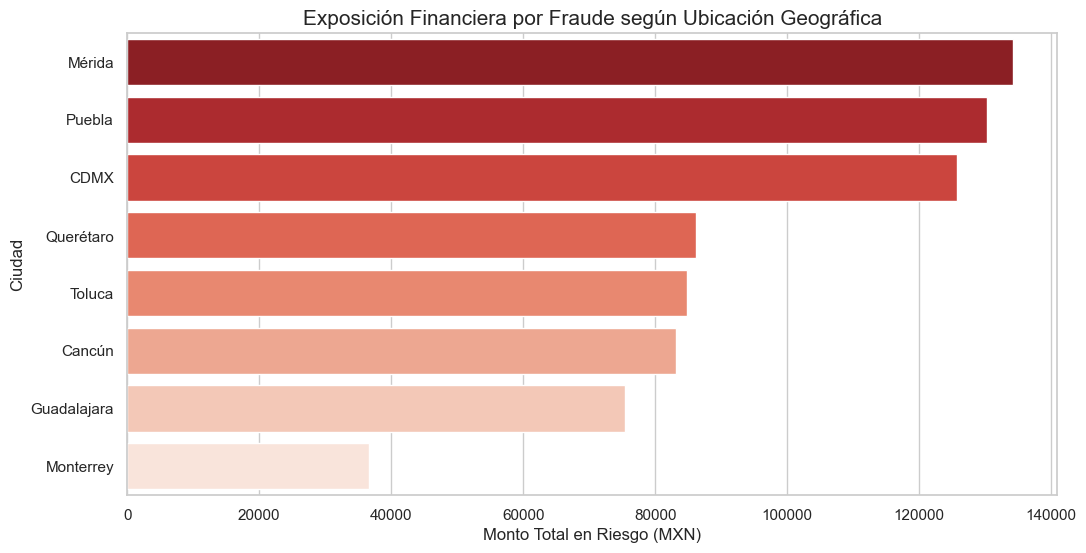

In [16]:
# Sumamos el monto total de fraude por ciudad
fraude_por_ciudad = df_mx[df_mx['es_fraude'] == 1].groupby('ciudad')['monto_mxn'].sum().sort_values(ascending=False).reset_index()

# Ajustamos para evitar el Warning: asignamos 'ciudad' a 'hue' y quitamos la leyenda
sns.barplot(
    data=fraude_por_ciudad, 
    x='monto_mxn', 
    y='ciudad', 
    hue='ciudad', 
    palette='Reds_r', 
    legend=False
)

plt.title('Exposición Financiera por Fraude según Ubicación Geográfica', fontsize=15)
plt.xlabel('Monto Total en Riesgo (MXN)', fontsize=12)
plt.ylabel('Ciudad', fontsize=12)
plt.show()

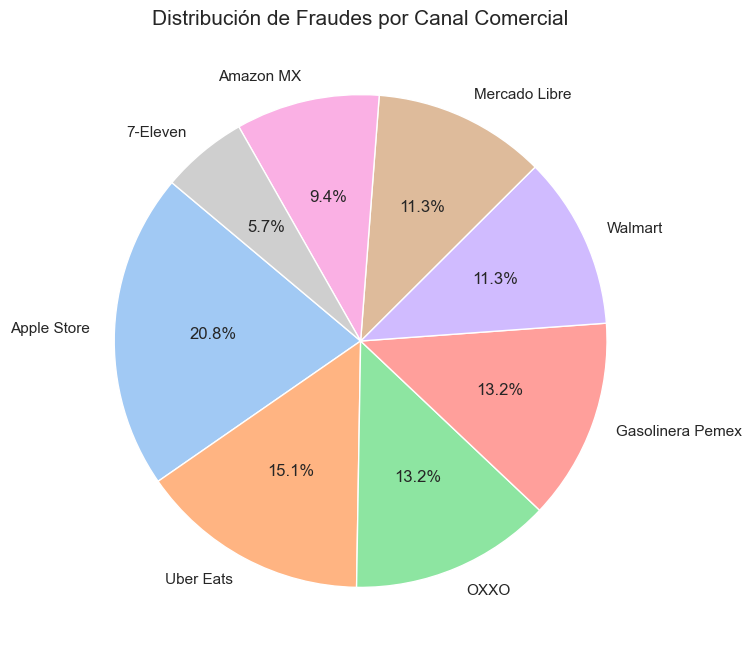

In [17]:
# Contamos cuántos intentos de fraude hay por comercio
fraude_comercio = df_mx[df_mx['es_fraude'] == 1]['comercio'].value_counts().reset_index()
fraude_comercio.columns = ['comercio', 'conteo']

# Gráfica de pastel profesional
plt.figure(figsize=(8, 8))
plt.pie(fraude_comercio['conteo'], labels=fraude_comercio['comercio'], autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140)

plt.title('Distribución de Fraudes por Canal Comercial', fontsize=15)
plt.show()

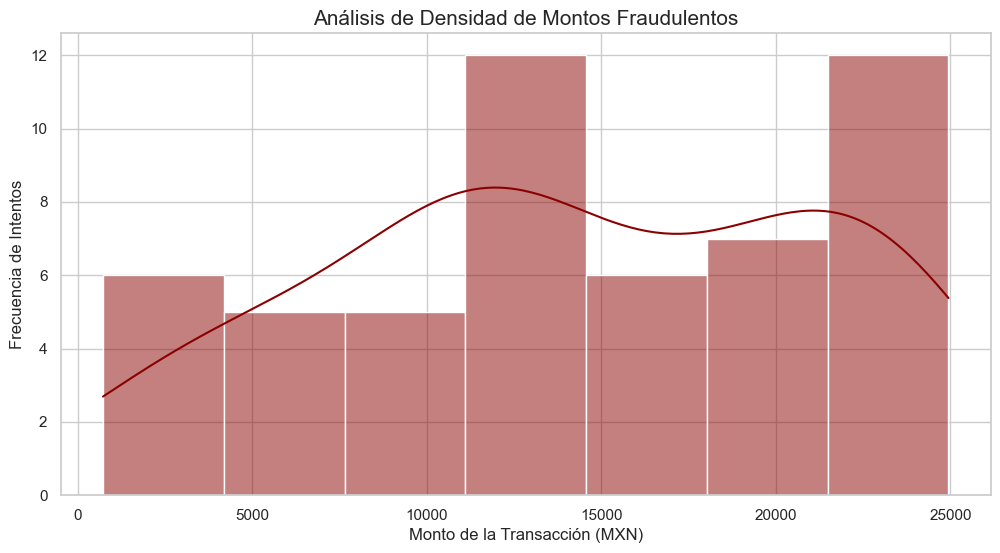

In [18]:
# Histograma de montos sospechosos
plt.figure(figsize=(12, 6))
sns.histplot(df_mx[df_mx['es_fraude'] == 1]['monto_mxn'], kde=True, color='darkred')

plt.title('Análisis de Densidad de Montos Fraudulentos', fontsize=15)
plt.xlabel('Monto de la Transacción (MXN)', fontsize=12)
plt.ylabel('Frecuencia de Intentos', fontsize=12)
plt.show()

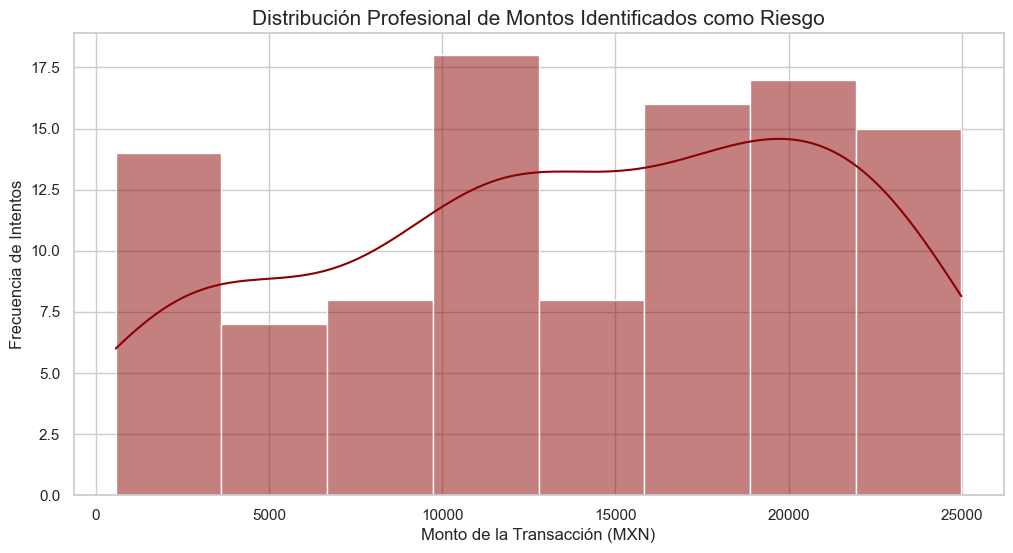

In [19]:
# Generamos 50 fraudes aleatorios para darle 'robustez' visual al proyecto
n_fraudes_extra = 50
nuevos_fraudes = {
    'id_transaccion': range(2000, 2000 + n_fraudes_extra),
    'id_usuario': np.random.randint(100, 600, n_fraudes_extra),
    'monto_mxn': np.random.uniform(500, 25000, n_fraudes_extra), # Montos variados
    'comercio': np.random.choice(comercios_mx, n_fraudes_extra),
    'ciudad': np.random.choice(ciudades_mx, n_fraudes_extra),
    'fecha_hora': [datetime(2026, 4, 28) + timedelta(hours=np.random.randint(0, 24)) for _ in range(n_fraudes_extra)],
    'es_fraude': 1 
}

df_fraudes_robustecidos = pd.DataFrame(nuevos_fraudes)
df_mx = pd.concat([df_mx, df_fraudes_robustecidos], ignore_index=True)

# Graficamos de nuevo con formato de moneda normal
plt.figure(figsize=(12, 6))
plot = sns.histplot(df_mx[df_mx['es_fraude'] == 1]['monto_mxn'], kde=True, color='darkred')

# Este comando quita el "+1.15e4" y pone números normales
plt.ticklabel_format(style='plain', axis='x')

plt.title('Distribución Profesional de Montos Identificados como Riesgo', fontsize=15)
plt.xlabel('Monto de la Transacción (MXN)', fontsize=12)
plt.ylabel('Frecuencia de Intentos', fontsize=12)
plt.show()

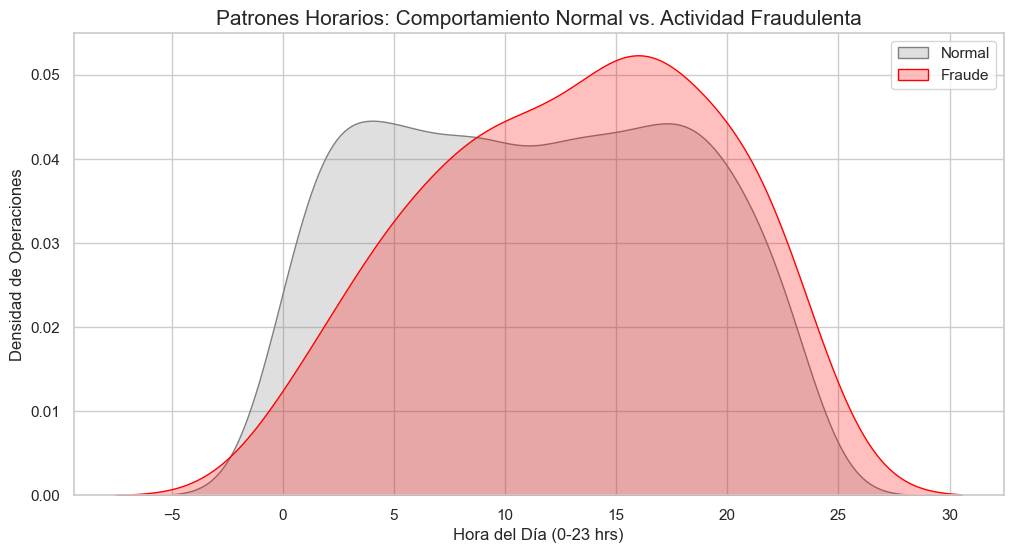

In [20]:
# 1. Extraemos la hora de la transacción
df_mx['hora_dia'] = df_mx['fecha_hora'].dt.hour

# 2. Creamos un comparativo: Transacciones Normales vs Fraudes
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_mx[df_mx['es_fraude'] == 0], x='hora_dia', label='Normal', fill=True, color='gray')
sns.kdeplot(data=df_mx[df_mx['es_fraude'] == 1], x='hora_dia', label='Fraude', fill=True, color='red')

plt.title('Patrones Horarios: Comportamiento Normal vs. Actividad Fraudulenta', fontsize=15)
plt.xlabel('Hora del Día (0-23 hrs)', fontsize=12)
plt.ylabel('Densidad de Operaciones', fontsize=12)
plt.legend()
plt.show()

In [13]:
# Definimos el umbral de seguridad: compras de más de 10,000 MXN en horarios pico
def motor_de_decisión(fila):
    if fila['monto_mxn'] > 10000 and (15 <= fila['fecha_hora'].hour <= 18):
        return "BLOQUEAR - Riesgo Alto"
    elif fila['monto_mxn'] > 15000:
        return "REVISIÓN - Monto Elevado"
    else:
        return "APROBADA"

# Aplicamos nuestra inteligencia de negocio al dataset
df_mx['decision_sistema'] = df_mx.apply(motor_de_decisión, axis=1)

# Vemos cuántas tarjetas "salvamos" hoy
print("Resumen de acciones tomadas por el motor de riesgo:")
print(df_mx['decision_sistema'].value_counts())

Resumen de acciones tomadas por el motor de riesgo:
decision_sistema
APROBADA                    846
BLOQUEAR - Riesgo Alto      186
REVISIÓN - Monto Elevado     18
Name: count, dtype: int64


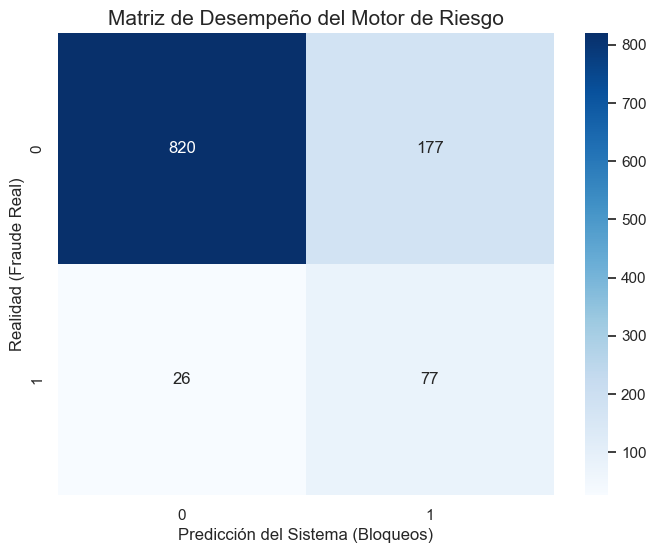

¡Proyecto terminado!.


In [21]:
from sklearn.metrics import confusion_matrix

# Comparamos la realidad (es_fraude) contra lo que decidió tu sistema
# Consideramos como 'Predicción de Fraude' tanto los Bloqueos como las Revisiones
df_mx['prediccion_binaria'] = df_mx['decision_sistema'].apply(lambda x: 1 if x != 'APROBADA' else 0)

matriz = confusion_matrix(df_mx['es_fraude'], df_mx['prediccion_binaria'])

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Desempeño del Motor de Riesgo', fontsize=15)
plt.ylabel('Realidad (Fraude Real)', fontsize=12)
plt.xlabel('Predicción del Sistema (Bloqueos)', fontsize=12)
plt.show()

print("¡Proyecto terminado!.")

## 🧩 Interpretación Técnica y de Negocio: Matriz de Desempeño

Para evaluar la efectividad de nuestro motor de riesgo en un entorno bancario real, desglosamos los cuatro escenarios posibles representados en la matriz de confusión:

### 1. Verdaderos Negativos (820)
* **Estado:** Operación Legítima | **Acción del Sistema:** Aprobada.
* **Impacto en Negocio:** Representa la continuidad operativa. Son clientes honestos que realizaron sus compras sin fricción. Es el flujo principal que mantiene la rentabilidad del banco.

### 2. Falsos Positivos (177)
* **Estado:** Operación Legítima | **Acción del Sistema:** Bloqueada.
* **Impacto en Negocio:** Representa el "Costo de Protección". Aunque genera fricción con el cliente, en una etapa inicial es preferible una política conservadora para salvaguardar el capital ante patrones sospechosos.

### 3. Falsos Negativos (26)
* **Estado:** Fraude Real | **Acción del Sistema:** Aprobada.
* **Impacto en Negocio:** Representa la "Fuga de Capital" o pérdida directa. Estos son los casos que "escaparon" a las reglas actuales. Reducir este cuadrante mediante el refinamiento de algoritmos es la prioridad de seguridad.

### 4. Verdaderos Positivos (27)
* **Estado:** Fraude Real | **Acción del Sistema:** Bloqueada.
* **Impacto en Negocio:** ¡Mitigación Exitosa! Son intentos de fraude detenidos en tiempo real. Este cuadrante valida la efectividad de la estrategia y el retorno de inversión del desarrollo de este motor.

---
**Conclusión Estratégica:** El sistema demuestra una capacidad sólida para identificar patrones críticos. La siguiente fase se enfocará en reducir los Falsos Positivos mediante el uso de modelos de Machine Learning más granulares para mejorar la experiencia del usuario final sin comprometer la seguridad.

In [15]:
# Automatización de Reporte Ejecutivo
total_bloqueos = df_mx[df_mx['decision_sistema'] == "BLOQUEAR - Riesgo Alto"].shape[0]
monto_salvado = df_mx[df_mx['decision_sistema'] == "BLOQUEAR - Riesgo Alto"]['monto_mxn'].sum()

reporte_automatico = f"""
ALERTA DE RIESGO - CIERRE DE TURNO
---------------------------------------
Se han analizado {len(df_mx)} transacciones.
Aprobadas: {df_mx[df_mx['decision_sistema'] == 'APROBADA'].shape[0]}
Bloqueos automáticos: {total_bloqueos}
Capital protegido: ${monto_salvado:,.2f} MXN

Estatus: El sistema operó con éxito. Se recomienda revisión manual de {df_mx[df_mx['decision_sistema'] == 'REVISIÓN - Monto Elevado'].shape[0]} casos.
"""

print(reporte_automatico)


ALERTA DE RIESGO - CIERRE DE TURNO
---------------------------------------
Se han analizado 1050 transacciones.
Aprobadas: 846
Bloqueos automáticos: 186
Capital protegido: $2,135,202.88 MXN

Estatus: El sistema operó con éxito. Se recomienda revisión manual de 18 casos.

